<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FResNet50-Model/ResNet50Model_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import json

from tensorflow.keras import layers, models

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

TRAIN_PATH = os.path.join(DATASET_PATH,"Train")
VAL_PATH = os.path.join(DATASET_PATH,"Validation")
TEST_PATH = os.path.join(DATASET_PATH,"Test")

In [20]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

NUM_CLASSES = 3

EPOCHS = 30

FINE_TUNE_FROM = 140

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2680 files belonging to 3 classes.
Found 574 files belonging to 3 classes.
Found 573 files belonging to 3 classes.


In [7]:
class_names = train_ds.class_names

print(class_names)

['Eczema', 'Leishmaniasis', 'Tinea']


In [10]:
class_mapping = {
    i:name
    for i,name in enumerate(class_names)
}


with open(
"/content/drive/MyDrive/dataset/class_names4.json",
"w"
) as f:

    json.dump(
        class_mapping,
        f,
        indent=4
    )

In [11]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.03
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomContrast(
        0.10
    )

])

In [12]:
AUTOTUNE=tf.data.AUTOTUNE


train_ds=train_ds.prefetch(AUTOTUNE)
val_ds=val_ds.prefetch(AUTOTUNE)
test_ds=test_ds.prefetch(AUTOTUNE)

In [13]:
base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )

)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable=True


for layer in base_model.layers:

    layer.trainable=False

In [15]:
for layer in base_model.layers[FINE_TUNE_FROM:]:

    layer.trainable=True

In [16]:
inputs=tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)


x=data_augmentation(inputs)


x=preprocess_input(x)


x=base_model(
    x,
    training=False
)


x=layers.GlobalAveragePooling2D()(x)


x=layers.Dense(
    256,
    activation="relu"
)(x)


x=layers.Dropout(
    0.5
)(x)


outputs=layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model=tf.keras.Model(
    inputs,
    outputs
)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 15,503,363 (59.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [18]:
model.compile(

    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [19]:
callbacks=[

tf.keras.callbacks.ModelCheckpoint(

filepath="/content/drive/MyDrive/dataset/resnet50_model4_best.keras",

monitor="val_accuracy",

save_best_only=True,

mode="max",

verbose=1

),


tf.keras.callbacks.EarlyStopping(

monitor="val_loss",

patience=7,

restore_best_weights=True

),


tf.keras.callbacks.ReduceLROnPlateau(

monitor="val_loss",

factor=0.2,

patience=3,

min_lr=1e-7

)

]

In [21]:
history=model.fit(

train_ds,

validation_data=val_ds,

epochs=EPOCHS,

callbacks=callbacks

)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5165 - loss: 1.1087 
Epoch 1: val_accuracy improved from None to 0.83798, saving model to /content/drive/MyDrive/dataset/resnet50_model4_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset/resnet50_model4_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 1071s 13s/step - accuracy: 0.6358 - loss: 0.8475 - val_accuracy: 0.8380 - val_loss: 0.3957 - learning_rate: 1.0000e-05
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8366 - loss: 0.4157 
Epoch 2: val_accuracy improved from 0.83798 to 0.91115, saving model to /content/drive/MyDrive/dataset/resnet50_model4_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset/resnet50_model4_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 1068s 13s/step - accuracy: 0.8627 - loss: 0.3637 - val_accuracy: 0.9111 - val_loss: 0.2428 - learning_rate: 1.0000e-05
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9300 - loss: 0.2176 
Epoch 3: v

In [28]:
test_results = model.evaluate(
    test_ds,
    return_dict=True
)

print(test_results)

18/18 ━━━━━━━━━━━━━━━━━━━━ 133s 7s/step - accuracy: 0.9895 - loss: 0.0326
{'accuracy': 0.9895287752151489, 'loss': 0.032551802694797516}


In [29]:
model.save(
"/content/drive/MyDrive/dataset/resnet50_model4_final.keras"
)

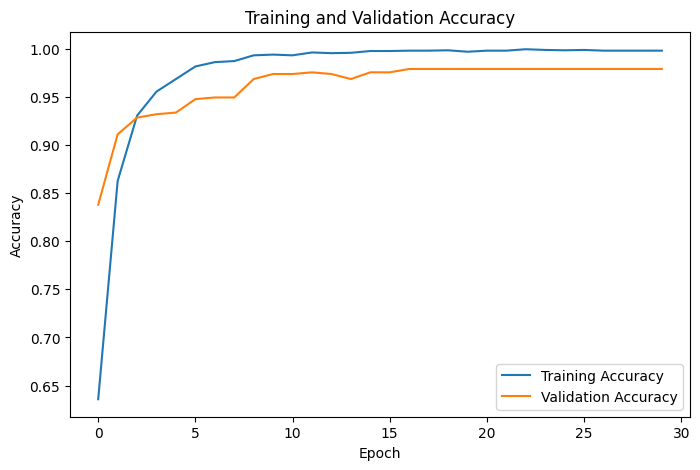

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

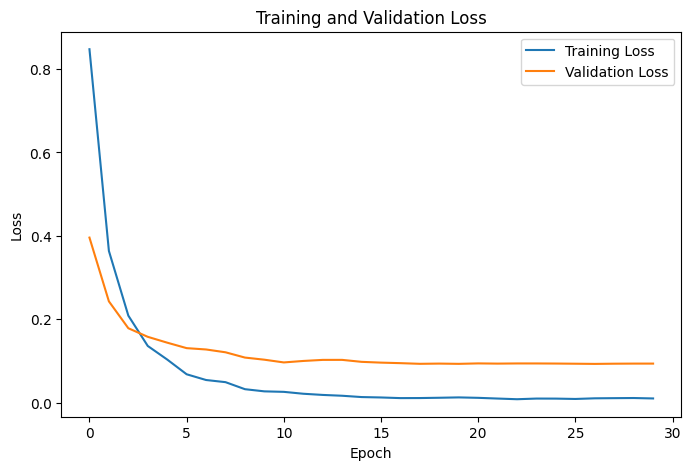

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [33]:
y_true = []

y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    # labels.numpy() already returns the integer class indices (e.g., [0, 1, 2, ...])
    # so argmax is not needed here and causes the AxisError.
    actual_classes = labels.numpy()

    y_true.extend(actual_classes)

    y_pred.extend(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


In [34]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

               precision    recall  f1-score   support

       Eczema       1.00      0.99      1.00       232
Leishmaniasis       0.99      0.96      0.98       113
        Tinea       0.98      1.00      0.99       228

     accuracy                           0.99       573
    macro avg       0.99      0.99      0.99       573
 weighted avg       0.99      0.99      0.99       573



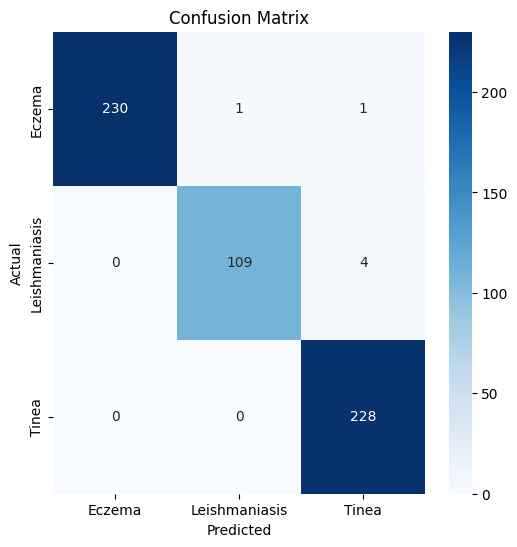

In [36]:
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

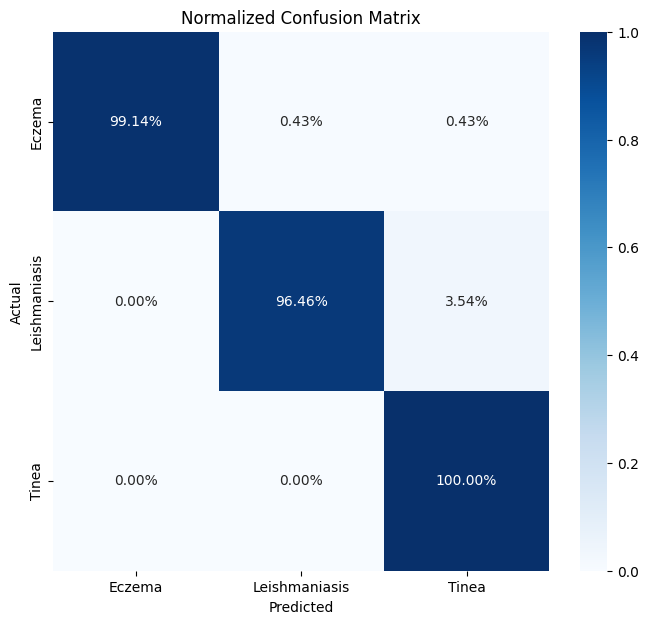

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix by row (actual class totals)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%", # Changed format to display as percentages
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [38]:
y_true = []
y_score = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_score.extend(predictions)

y_true = np.array(y_true)
y_score = np.array(y_score)

In [39]:
n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

In [40]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

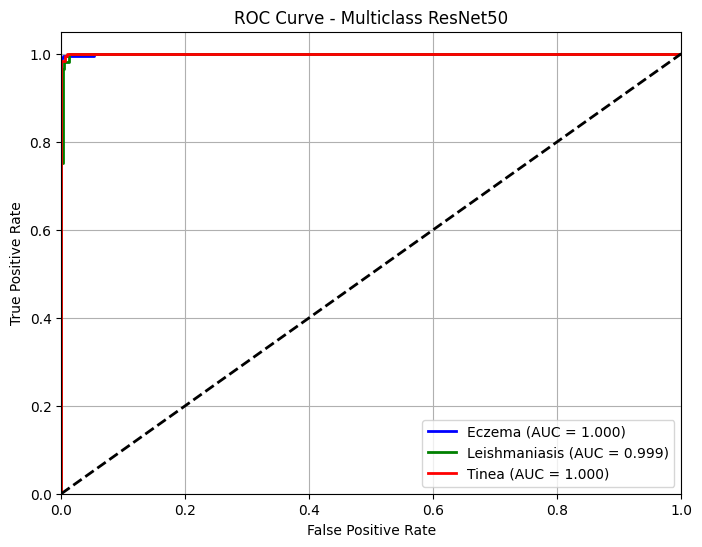

In [41]:
plt.figure(figsize=(8,6))

colors = ["blue", "green", "red"]

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=2
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multiclass ResNet50")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [42]:
print("AUC Scores")

for i in range(n_classes):
    print(f"{class_names[i]} : {roc_auc[i]:.4f}")

AUC Scores
Eczema : 0.9998
Leishmaniasis : 0.9992
Tinea : 0.9999


In [57]:
from google.colab import files

uploaded = files.upload()

Saving test1.jfif to test1 (1).jfif


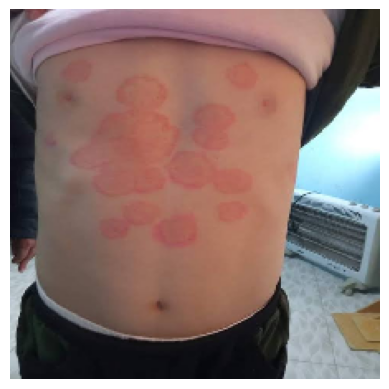

In [58]:
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = load_img(image_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [59]:
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

In [60]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
[[0.00216983 0.05721774 0.9406124 ]]


In [61]:
predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

Predicted Class : Tinea
Confidence      : 94.06%


In [62]:
print("Prediction Probabilities\n")

for i, class_name in enumerate(class_names):
    print(f"{class_name:15s}: {prediction[0][i]*100:.2f}%")

Prediction Probabilities

Eczema         : 0.22%
Leishmaniasis  : 5.72%
Tinea          : 94.06%


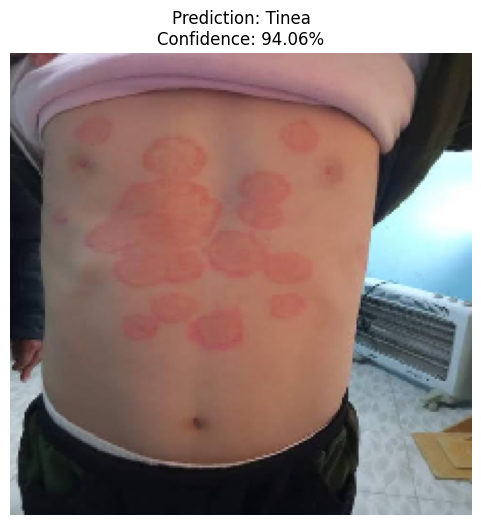

In [63]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()